# Manufacturing Equipment Output Prediction
## Linear Regression Model for Production Optimization

**Objective:** Predict hourly machine output (Parts_Per_Hour) based on operating parameters

**Author:** Data Science Team  
**Date:** 2024

## 1. Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Modeling
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# Save models
import joblib
import json

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [3]:
# Load data
df = pd.read_csv('../data/manufacturing_dataset_1000_samples.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (1000, 19)

Columns: ['Timestamp', 'Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']

First 5 rows:


,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2024-01-01 00:00:00,227.450712,93.993554,39.598574,12.368770,456.825320,23.728721,6,11.0,4.403739,Night,Type_A,Premium,Sunday,2.419854,51.967344,117.711217,91.509559,100.724971
1,2024-01-01 01:00:00,217.926035,89.246337,43.843851,16.558460,NaN,23.639758,9,19.0,1.695175,Day,Type_B,Premium,Wednesday,2.441849,60.402311,115.585526,101.621851,101.084925
2,2024-01-01 02:00:00,229.715328,80.596304,38.660641,18.345578,500.900844,19.613070,7,10.0,4.832196,Night,Type_B,Premium,Tuesday,2.850197,57.006218,115.496589,85.620232,81.731076
3,2024-01-01 03:00:00,242.845448,73.530632,42.536308,27.550751,523.631517,24.009729,14,12.0,4.232631,Day,Type_A,Standard,Monday,3.302643,70.087058,102.697894,75.166451,77.718246
4,2024-01-01 04:00:00,216.487699,86.982233,29.851083,22.226212,431.657082,27.198487,11,1.0,6.160146,Evening,Type_A,Economy,Monday,2.488873,52.077295,97.980437,77.466204,77.394339


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("Dataset Information:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Statistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   str    
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   int64  
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   float64
 10  Shift                       1000 non-null   str    
 11  Machine_Type                1000 non-null   str    
 12  Material_Grade              1000 non-null   str    
 13  Day_of_Week             

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,980.000000,980.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,220.289981,80.708362,45.046674,19.925123,497.483475,24.847872,7.515000,10.297959,4.960206,2.774375,64.971797,115.300618,84.674672,81.491584
std,14.688239,9.974544,7.867634,4.108530,49.851751,3.001325,4.003974,5.344801,2.045701,0.412826,8.954061,12.558206,10.137226,12.586293
min,171.380990,50.596114,20.843903,8.282205,341.164809,16.301458,1.000000,1.000000,-1.432114,1.852278,33.364936,81.421119,53.252511,50.000000
25%,210.286145,73.937583,39.816003,17.050318,465.439296,22.935627,4.000000,6.000000,3.567784,2.476358,58.864476,106.817043,77.811737,73.134172
50%,220.379509,80.630771,44.997994,20.000738,498.945652,24.862727,7.000000,10.500000,4.964387,2.725314,65.107403,115.495409,84.717951,80.853548
75%,229.719158,87.288822,50.287323,22.667782,532.284617,26.826800,11.000000,15.000000,6.362670,3.012400,71.161169,124.034997,91.444677,90.248599
max,277.790972,111.931076,76.409902,32.972372,655.645510,34.294898,14.000000,19.000000,11.552799,4.216576,100.416429,149.266653,116.555379,119.263563


Missing Values Analysis:
                     Missing Count  Percentage
Operator_Experience             20         2.0
Material_Viscosity              20         2.0
Ambient_Temperature             20         2.0


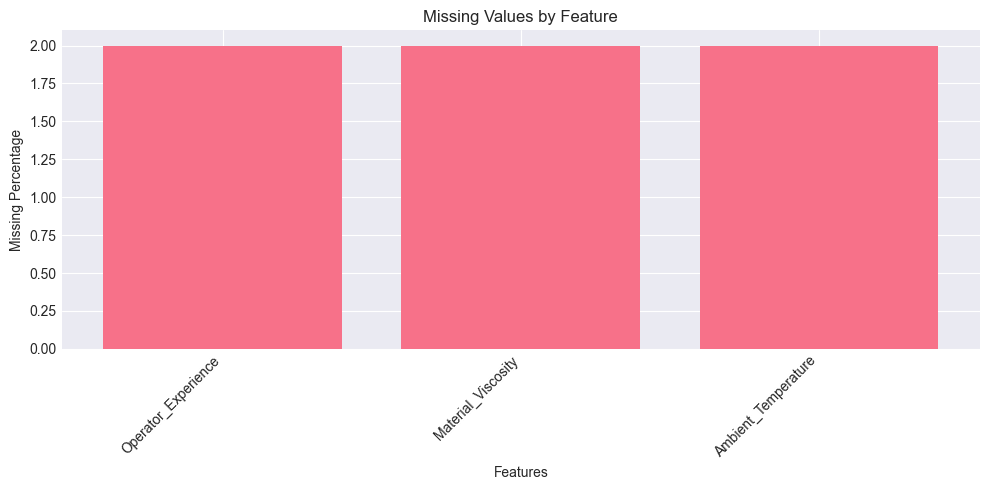

In [5]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 5))
missing_cols = missing_df[missing_df['Missing Count'] > 0]
if len(missing_cols) > 0:
    plt.bar(missing_cols.index, missing_cols['Percentage'])
    plt.xlabel('Features')
    plt.ylabel('Missing Percentage')
    plt.title('Missing Values by Feature')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()

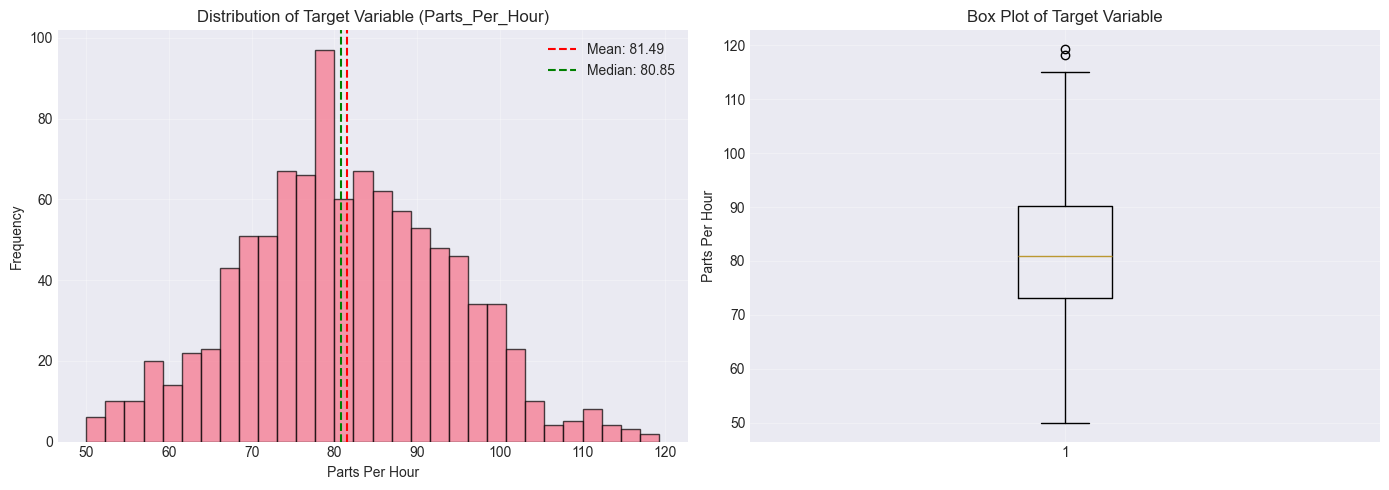

Target Variable Statistics:
Mean: 81.49
Median: 80.85
Std Dev: 12.59
Min: 50.00
Max: 119.26
Skewness: 0.08
Kurtosis: -0.18


In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Parts_Per_Hour'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Parts_Per_Hour'].mean(), color='red', linestyle='--', label=f'Mean: {df["Parts_Per_Hour"].mean():.2f}')
axes[0].axvline(df['Parts_Per_Hour'].median(), color='green', linestyle='--', label=f'Median: {df["Parts_Per_Hour"].median():.2f}')
axes[0].set_xlabel('Parts Per Hour')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Variable (Parts_Per_Hour)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['Parts_Per_Hour'], vert=True)
axes[1].set_ylabel('Parts Per Hour')
axes[1].set_title('Box Plot of Target Variable')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Target Variable Statistics:")
print(f"Mean: {df['Parts_Per_Hour'].mean():.2f}")
print(f"Median: {df['Parts_Per_Hour'].median():.2f}")
print(f"Std Dev: {df['Parts_Per_Hour'].std():.2f}")
print(f"Min: {df['Parts_Per_Hour'].min():.2f}")
print(f"Max: {df['Parts_Per_Hour'].max():.2f}")
print(f"Skewness: {df['Parts_Per_Hour'].skew():.2f}")
print(f"Kurtosis: {df['Parts_Per_Hour'].kurtosis():.2f}")

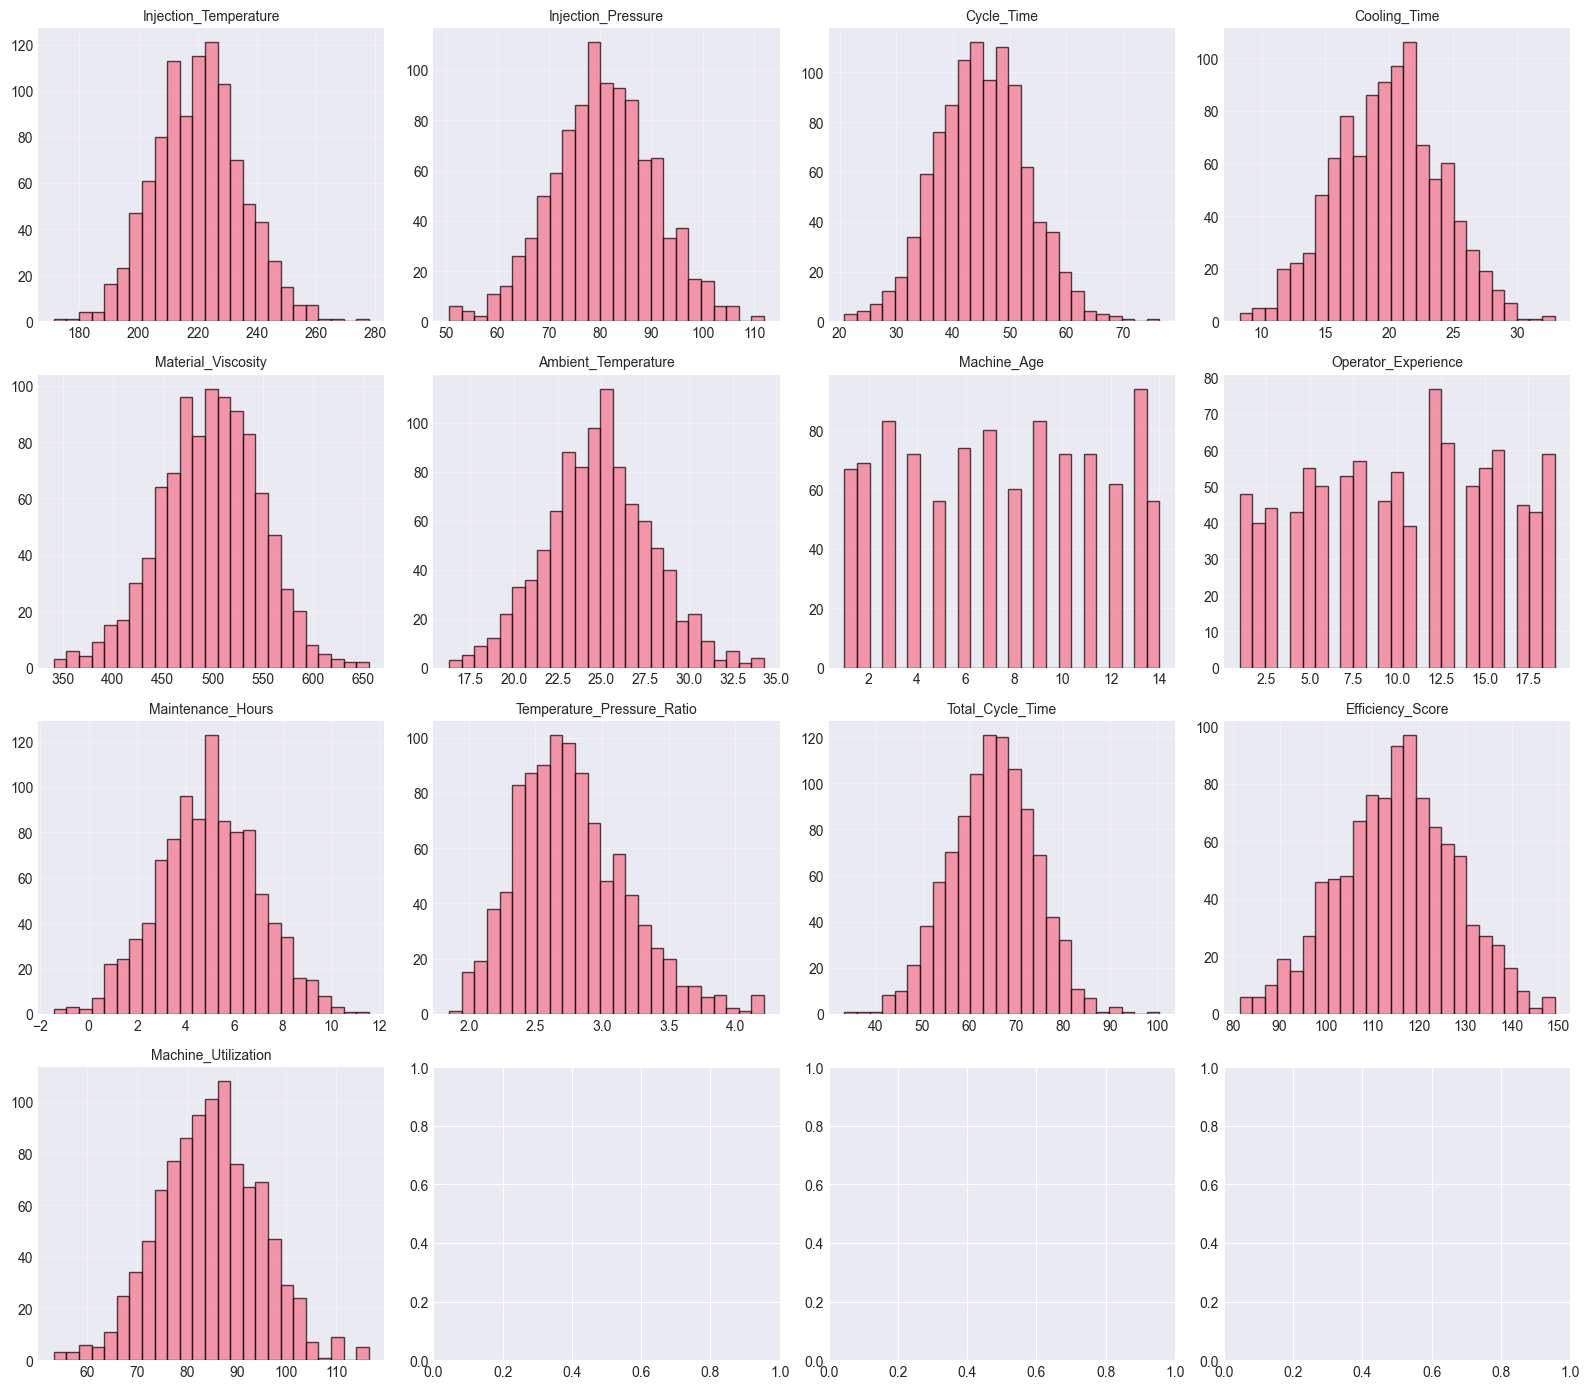

In [7]:
# Numerical features distribution
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Parts_Per_Hour')

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:16]):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

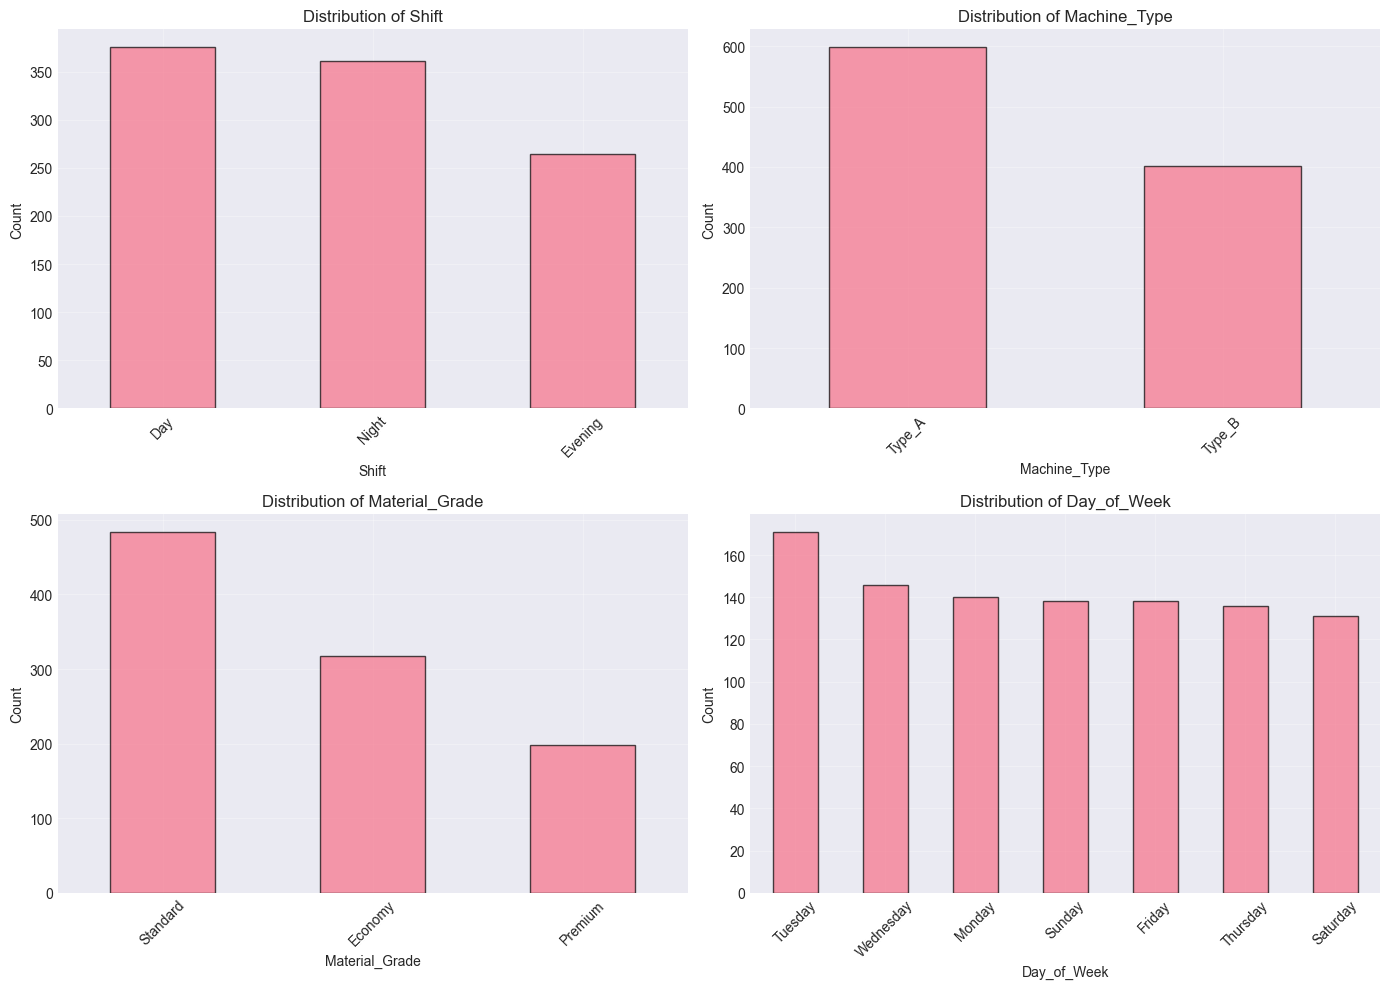

In [8]:
# Categorical features analysis
categorical_cols = ['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

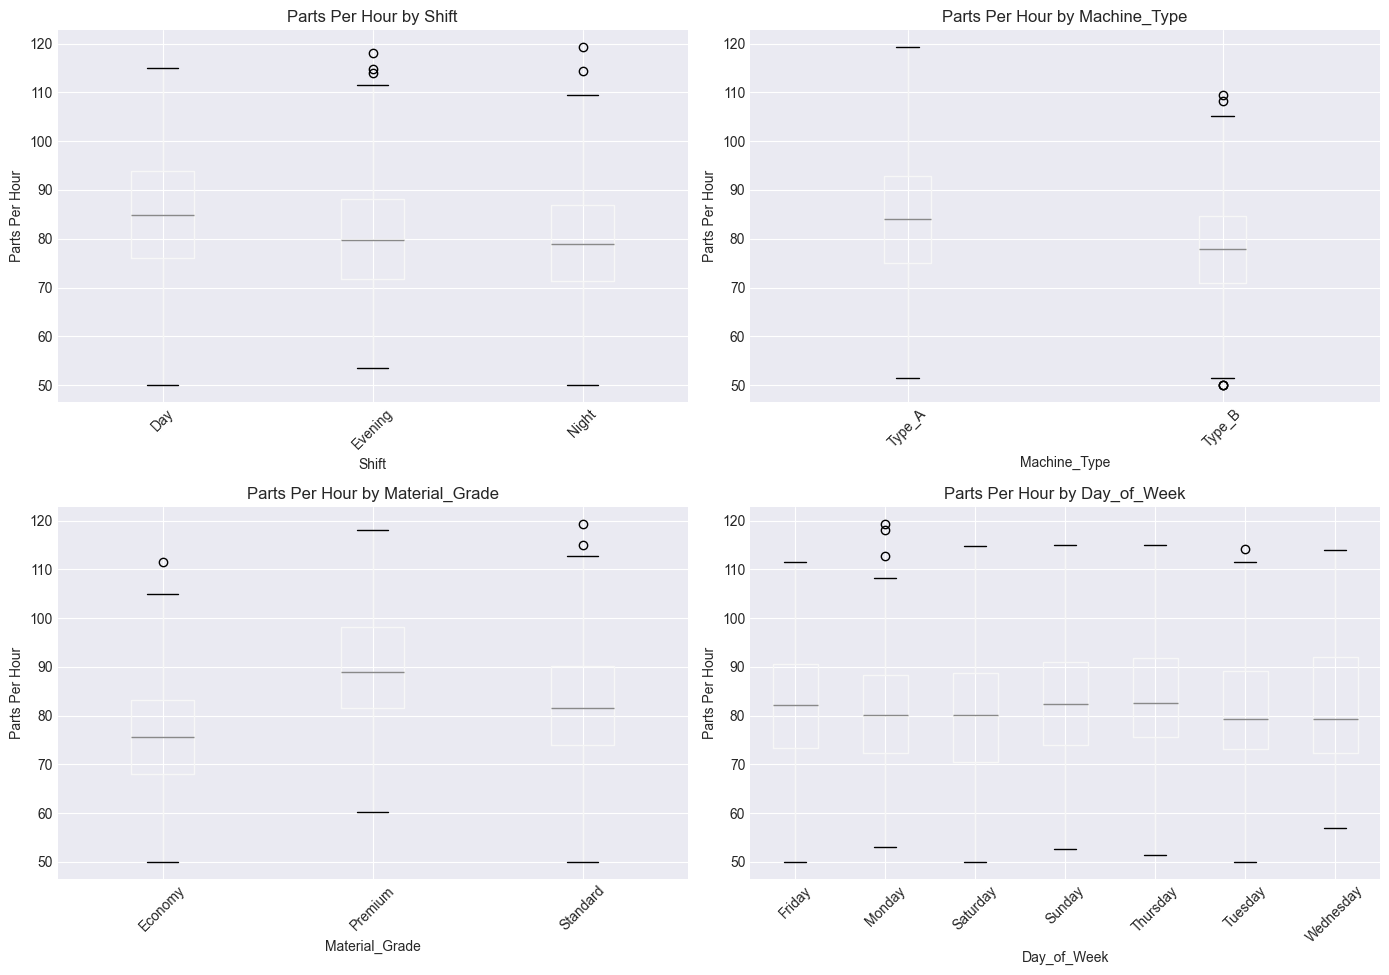

In [9]:
# Categorical features vs target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df.boxplot(column='Parts_Per_Hour', by=col, ax=axes[i])
    axes[i].set_title(f'Parts Per Hour by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Parts Per Hour')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/categorical_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()

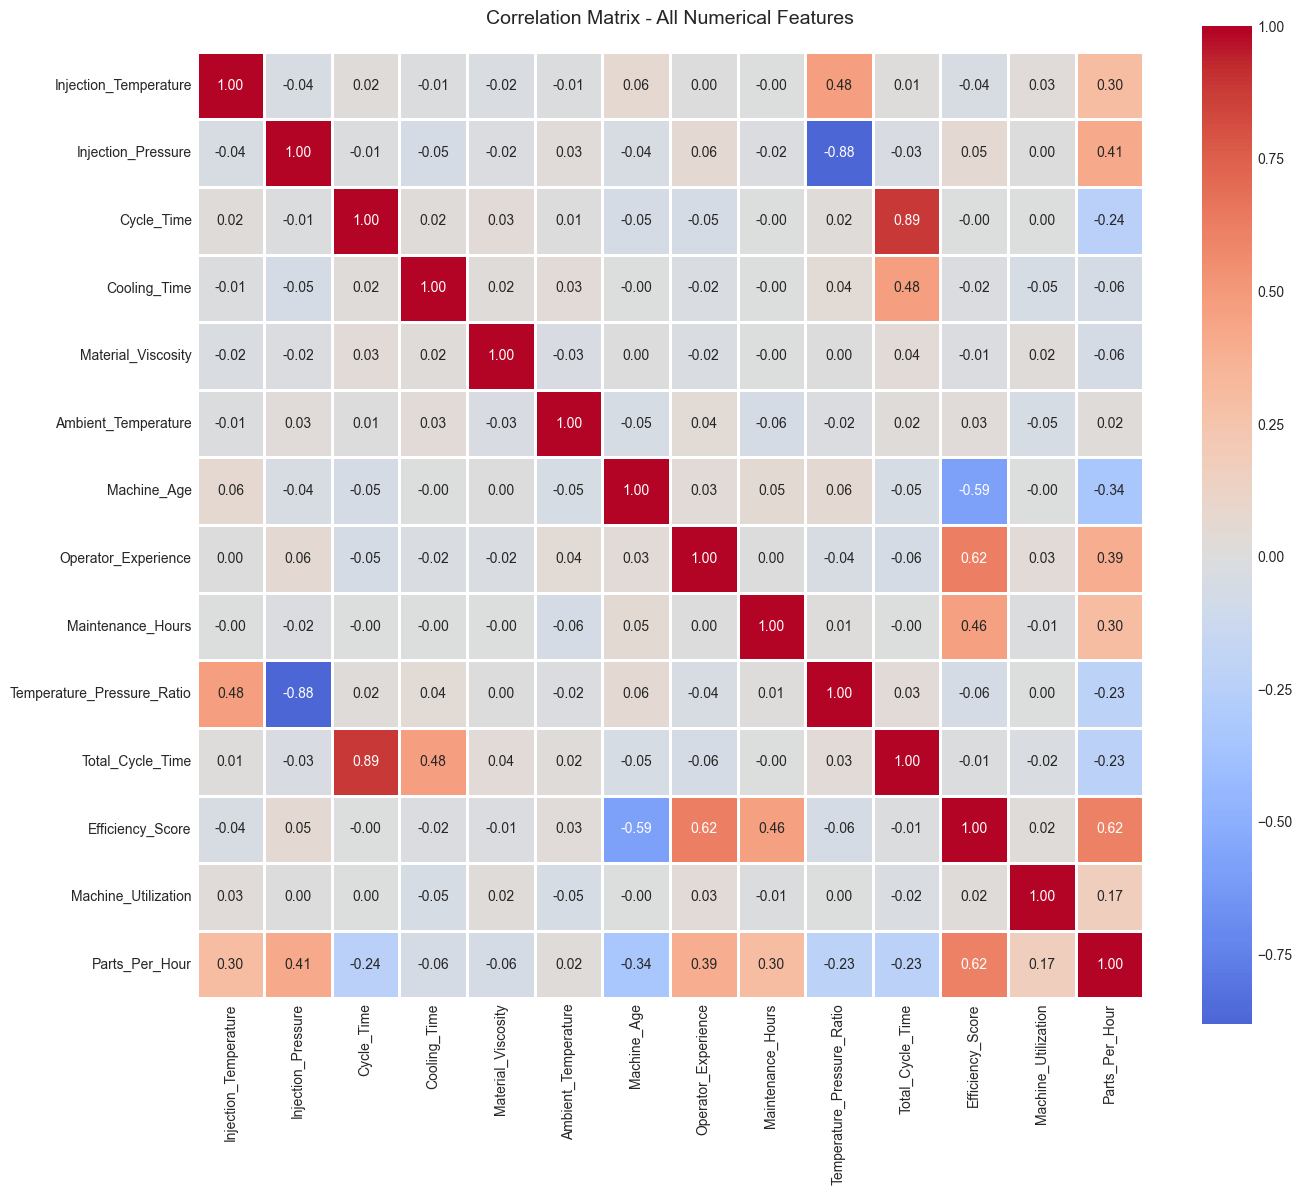


Top 10 Features Correlated with Target:
Efficiency_Score              0.617310
Injection_Pressure            0.414504
Operator_Experience           0.392342
Machine_Age                   0.344488
Maintenance_Hours             0.301621
Injection_Temperature         0.297083
Cycle_Time                    0.235962
Total_Cycle_Time              0.234063
Temperature_Pressure_Ratio    0.225639
Machine_Utilization           0.168902
Name: Parts_Per_Hour, dtype: float64


In [10]:
# Correlation analysis
plt.figure(figsize=(14, 12))
correlation_matrix = df[numerical_cols + ['Parts_Per_Hour']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - All Numerical Features', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = correlation_matrix['Parts_Per_Hour'].abs().sort_values(ascending=False)
print("\nTop 10 Features Correlated with Target:")
print(target_corr[1:11])

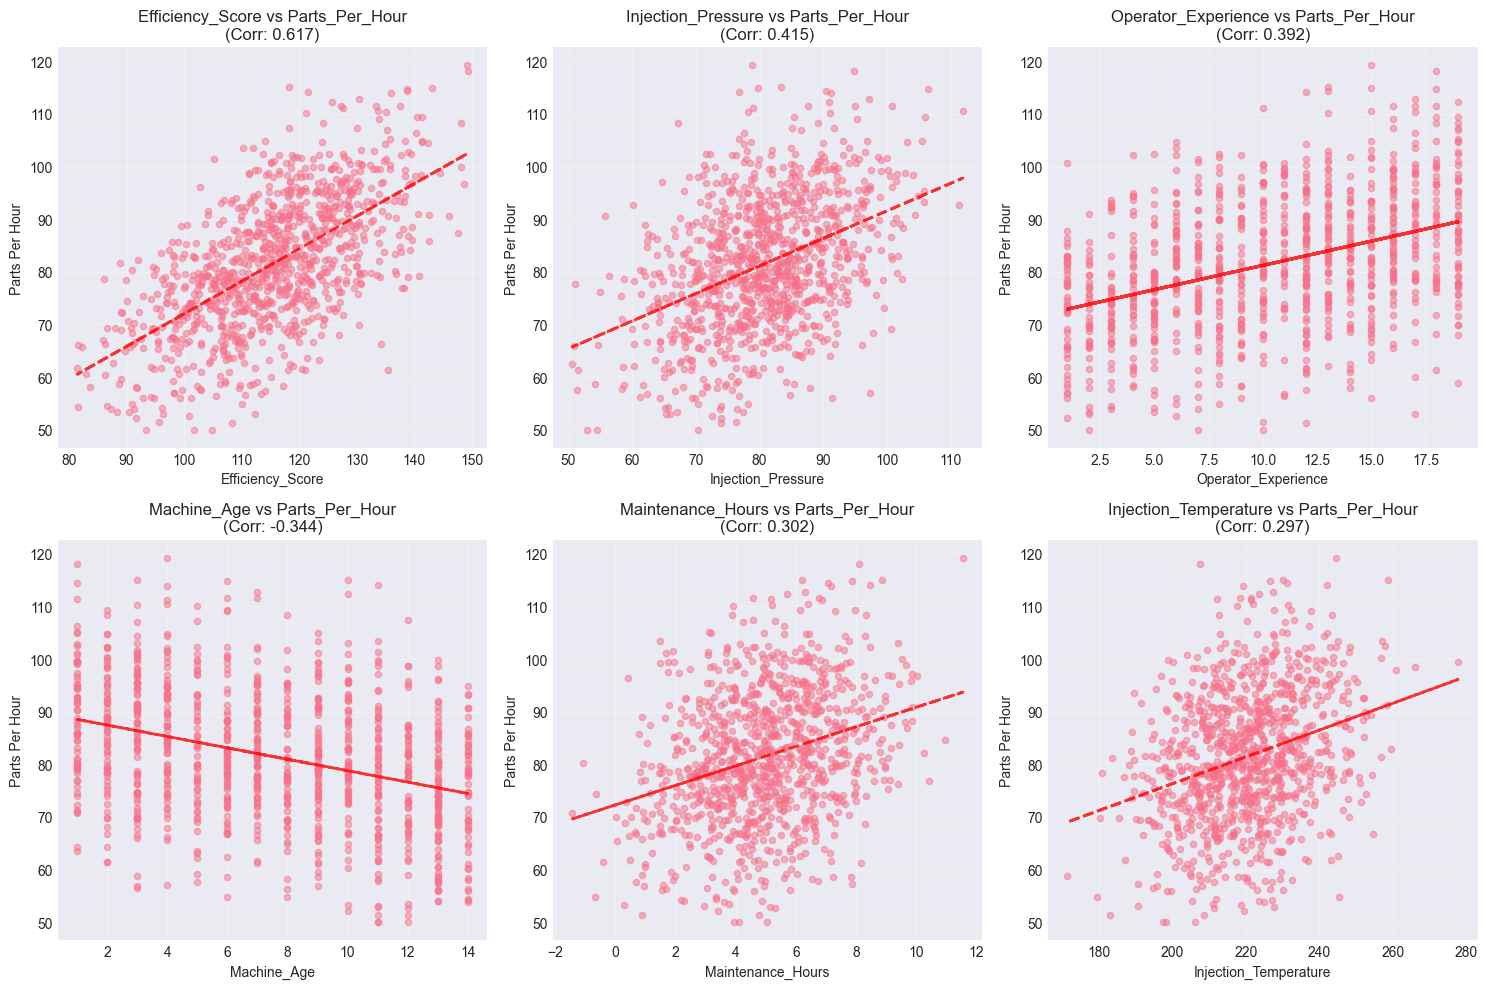

In [11]:
# Scatter plots: Top correlated features vs target
top_features = target_corr[1:7].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['Parts_Per_Hour'], alpha=0.5, s=20)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Parts Per Hour')
    axes[i].set_title(f'{feature} vs Parts_Per_Hour\n(Corr: {correlation_matrix.loc[feature, "Parts_Per_Hour"]:.3f})')
    axes[i].grid(alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df[feature].dropna(), df['Parts_Per_Hour'].loc[df[feature].dropna().index], 1)
    p = np.poly1d(z)
    axes[i].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('../reports/top_features_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Outlier detection using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), outliers.index

print("Outlier Analysis (IQR Method):")
print("=" * 50)
outlier_summary = {}
for col in numerical_cols + ['Parts_Per_Hour']:
    num_outliers, outlier_indices = detect_outliers_iqr(df, col)
    outlier_summary[col] = num_outliers
    if num_outliers > 0:
        print(f"{col}: {num_outliers} outliers ({num_outliers/len(df)*100:.2f}%)")

print(f"\nTotal features with outliers: {sum(1 for v in outlier_summary.values() if v > 0)}")

Outlier Analysis (IQR Method):
Injection_Temperature: 8 outliers (0.80%)
Injection_Pressure: 8 outliers (0.80%)
Cycle_Time: 10 outliers (1.00%)
Cooling_Time: 5 outliers (0.50%)
Material_Viscosity: 13 outliers (1.30%)
Ambient_Temperature: 11 outliers (1.10%)
Maintenance_Hours: 6 outliers (0.60%)
Temperature_Pressure_Ratio: 19 outliers (1.90%)
Total_Cycle_Time: 7 outliers (0.70%)
Machine_Utilization: 10 outliers (1.00%)
Parts_Per_Hour: 2 outliers (0.20%)

Total features with outliers: 11


## 4. Data Preprocessing

In [13]:
# Create a copy for preprocessing
df_processed = df.copy()

# 1. Drop Timestamp (not useful for regression)
df_processed = df_processed.drop('Timestamp', axis=1)
print("Dropped Timestamp column")

# 2. Handle missing values
print("\nHandling missing values...")
numerical_imputer = SimpleImputer(strategy='median')
missing_num_cols = ['Material_Viscosity', 'Ambient_Temperature', 'Operator_Experience']

for col in missing_num_cols:
    if col in df_processed.columns:
        df_processed[col] = numerical_imputer.fit_transform(df_processed[[col]])
        print(f"  - Imputed {col} with median")

print(f"\nMissing values after imputation: {df_processed.isnull().sum().sum()}")

Dropped Timestamp column

Handling missing values...
  - Imputed Material_Viscosity with median
  - Imputed Ambient_Temperature with median
  - Imputed Operator_Experience with median

Missing values after imputation: 0


In [14]:
# 3. Encode categorical variables
print("Encoding categorical variables...")

# One-hot encoding for nominal variables
df_processed = pd.get_dummies(df_processed, columns=['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week'], 
                               drop_first=True)

print(f"New shape after encoding: {df_processed.shape}")
print(f"New columns: {df_processed.columns.tolist()}")

Encoding categorical variables...
New shape after encoding: (1000, 25)
New columns: ['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour', 'Shift_Evening', 'Shift_Night', 'Machine_Type_Type_B', 'Material_Grade_Premium', 'Material_Grade_Standard', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday']


In [15]:
# 4. Separate features and target
X = df_processed.drop('Parts_Per_Hour', axis=1)
y = df_processed['Parts_Per_Hour']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (1000, 24)
Target shape: (1000,)

Feature columns (24):
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Shift_Evening', 'Shift_Night', 'Machine_Type_Type_B', 'Material_Grade_Premium', 'Material_Grade_Standard', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday']


In [16]:
# 5. Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target statistics:")
print(f"  Mean: {y_train.mean():.2f}")
print(f"  Std: {y_train.std():.2f}")
print(f"\nTest set target statistics:")
print(f"  Mean: {y_test.mean():.2f}")
print(f"  Std: {y_test.std():.2f}")

Training set size: 800 samples
Test set size: 200 samples

Training set target statistics:
  Mean: 81.56
  Std: 12.65

Test set target statistics:
  Mean: 81.23
  Std: 12.37


In [17]:
# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed using StandardScaler")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_train_scaled[:, 0].mean():.6f}")
print(f"Std of first feature (should be ~1): {X_train_scaled[:, 0].std():.6f}")

Feature scaling completed using StandardScaler

Scaled training data shape: (800, 24)
Mean of first feature (should be ~0): 0.000000
Std of first feature (should be ~1): 1.000000


## 5. Model Training & Evaluation

In [18]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a regression model
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred)
    }
    
    return metrics, model, y_train_pred, y_test_pred

In [19]:
# Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_models = {}
predictions = {}

print("Training models...\n")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    metrics, trained_model, y_train_pred, y_test_pred = evaluate_model(
        model, X_train_scaled, X_test_scaled, y_train, y_test, name
    )
    results.append(metrics)
    trained_models[name] = trained_model
    predictions[name] = {'train': y_train_pred, 'test': y_test_pred}
    print(f"  Test RMSE: {metrics['Test RMSE']:.4f}")
    print(f"  Test R²: {metrics['Test R²']:.4f}")

print("\n" + "=" * 80)
print("\nModel training completed!")

Training models...


Training Linear Regression...
  Test RMSE: 3.1002
  Test R²: 0.9369

Training Ridge Regression...
  Test RMSE: 3.1045
  Test R²: 0.9367

Training Lasso Regression...
  Test RMSE: 3.1719
  Test R²: 0.9339

Training Random Forest...
  Test RMSE: 6.5646
  Test R²: 0.7169

Training Gradient Boosting...
  Test RMSE: 4.5419
  Test R²: 0.8645


Model training completed!


In [20]:
# Results comparison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)
print("\nModel Comparison Results:")
print("=" * 80)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('../reports/model_comparison.csv', index=False)
print("\nResults saved to reports/model_comparison.csv")


Model Comparison Results:
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²  Train MSE  Test MSE
Linear Regression    2.904854   3.100233   2.347457  2.502238  0.947177 0.936858   8.438176  9.611444
 Ridge Regression    2.906082   3.104479   2.347525  2.501250  0.947132 0.936685   8.445312  9.637789
 Lasso Regression    2.939980   3.171872   2.374465  2.545773  0.945892 0.933906   8.643484 10.060769
Gradient Boosting    2.393723   4.541885   1.917762  3.634438  0.964131 0.864480   5.729911 20.628717
    Random Forest    2.380734   6.564628   1.885032  5.253214  0.964519 0.716892   5.667892 43.094340

Results saved to reports/model_comparison.csv


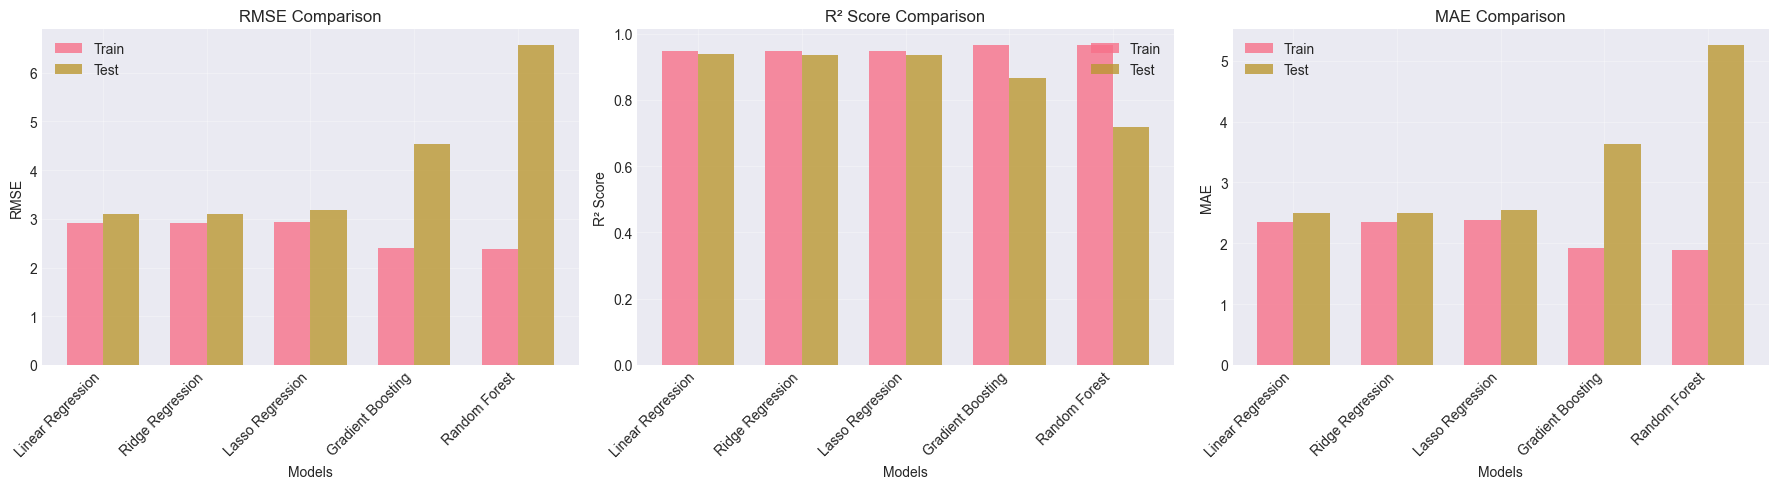

In [21]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
x = np.arange(len(results_df))
width = 0.35
axes[0].bar(x - width/2, results_df['Train RMSE'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, results_df['Test RMSE'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Models')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3)

# R² comparison
axes[1].bar(x - width/2, results_df['Train R²'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, results_df['Test R²'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Models')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3)

# MAE comparison
axes[2].bar(x - width/2, results_df['Train MAE'], width, label='Train', alpha=0.8)
axes[2].bar(x + width/2, results_df['Test MAE'], width, label='Test', alpha=0.8)
axes[2].set_xlabel('Models')
axes[2].set_ylabel('MAE')
axes[2].set_title('MAE Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Select best model (highest Test R²)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"\nTest Metrics:")
print(f"  RMSE: {results_df.iloc[0]['Test RMSE']:.4f}")
print(f"  MAE: {results_df.iloc[0]['Test MAE']:.4f}")
print(f"  R² Score: {results_df.iloc[0]['Test R²']:.4f}")
print(f"  MSE: {results_df.iloc[0]['Test MSE']:.4f}")


BEST MODEL: Linear Regression

Test Metrics:
  RMSE: 3.1002
  MAE: 2.5022
  R² Score: 0.9369
  MSE: 9.6114


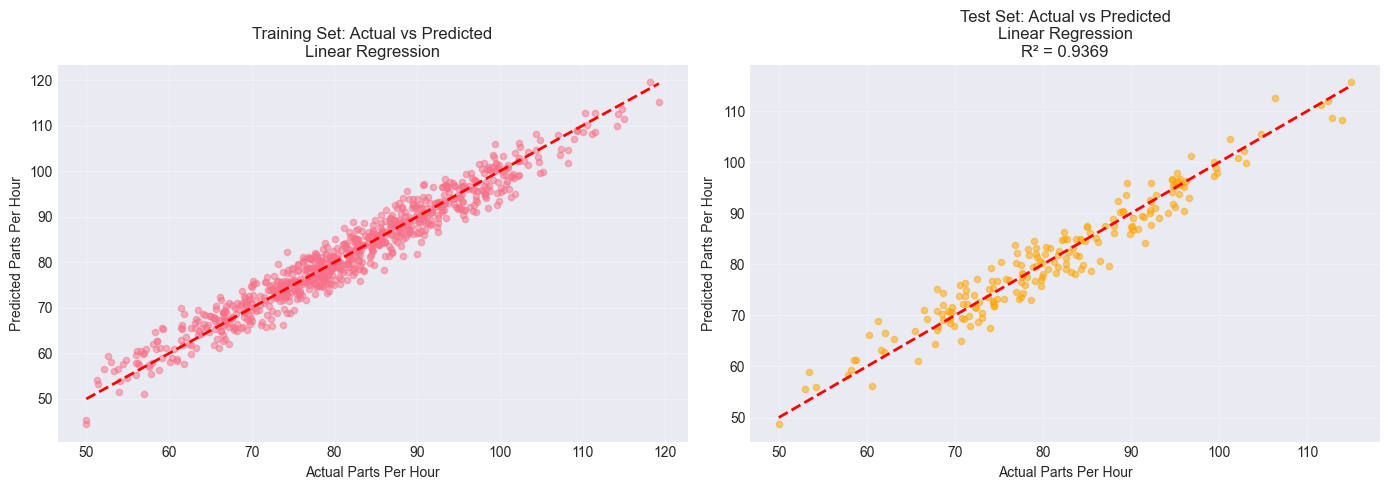

In [23]:
# Predicted vs Actual for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, best_predictions['train'], alpha=0.5, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Parts Per Hour')
axes[0].set_ylabel('Predicted Parts Per Hour')
axes[0].set_title(f'Training Set: Actual vs Predicted\n{best_model_name}')
axes[0].grid(alpha=0.3)

# Test set
axes[1].scatter(y_test, best_predictions['test'], alpha=0.5, s=20, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Parts Per Hour')
axes[1].set_ylabel('Predicted Parts Per Hour')
axes[1].set_title(f'Test Set: Actual vs Predicted\n{best_model_name}\nR² = {results_df.iloc[0]["Test R²"]:.4f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/best_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

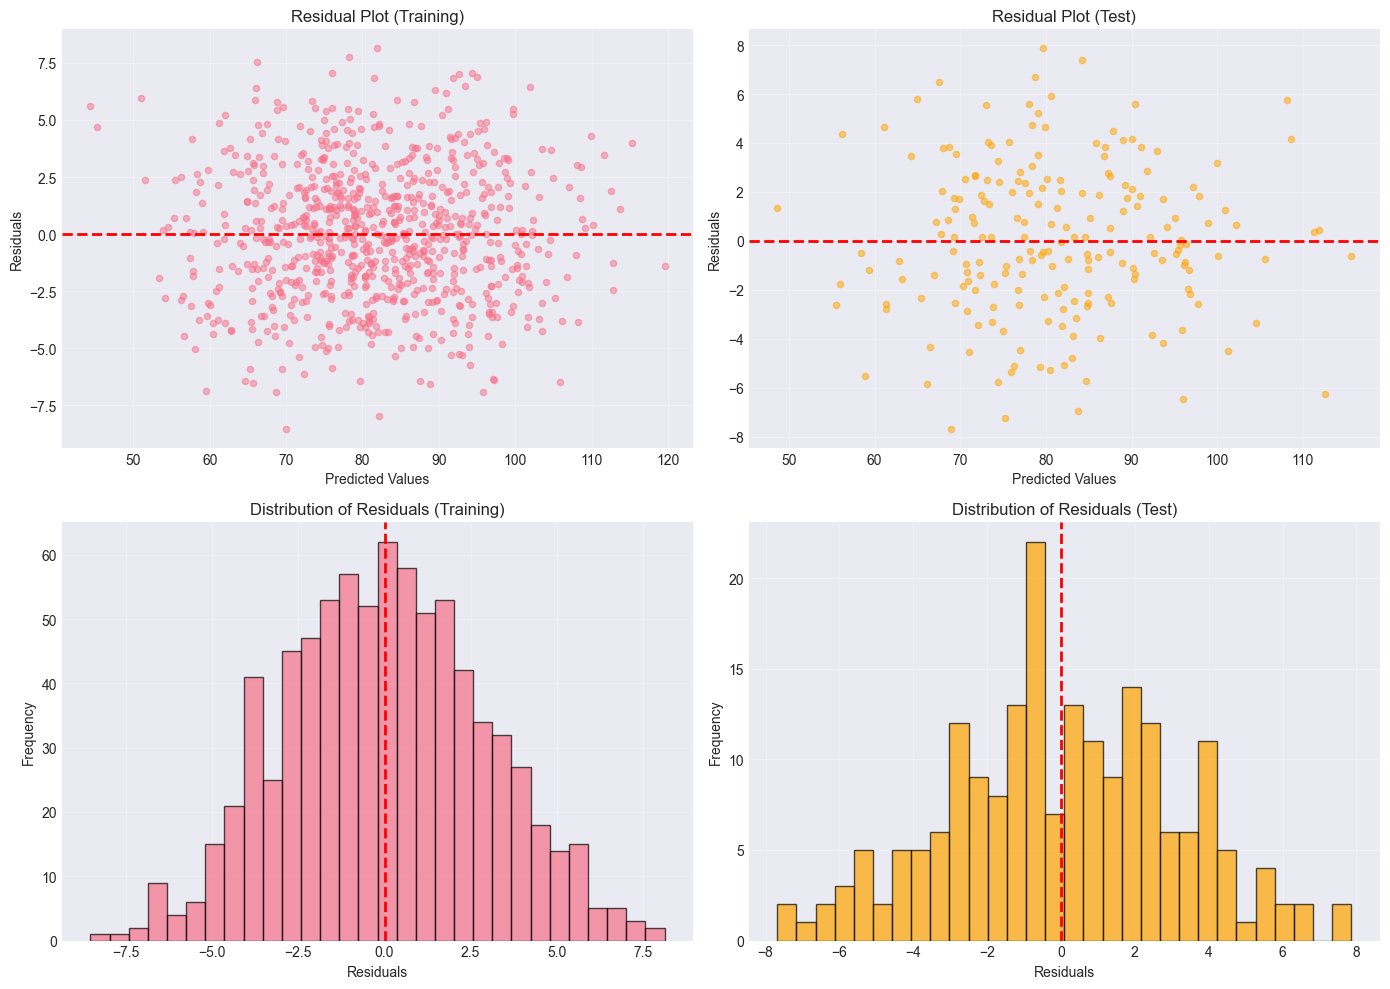

Residual Statistics (Test Set):
  Mean: 0.0359
  Std: 3.1078
  Min: -7.6832
  Max: 7.8610


In [24]:
# Residual analysis for best model
residuals_train = y_train - best_predictions['train']
residuals_test = y_test - best_predictions['test']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted (Train)
axes[0, 0].scatter(best_predictions['train'], residuals_train, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residual Plot (Training)')
axes[0, 0].grid(alpha=0.3)

# Residuals vs Predicted (Test)
axes[0, 1].scatter(best_predictions['test'], residuals_test, alpha=0.5, s=20, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot (Test)')
axes[0, 1].grid(alpha=0.3)

# Distribution of residuals (Train)
axes[1, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals (Training)')
axes[1, 0].grid(alpha=0.3)

# Distribution of residuals (Test)
axes[1, 1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals (Test)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residual Statistics (Test Set):")
print(f"  Mean: {residuals_test.mean():.4f}")
print(f"  Std: {residuals_test.std():.4f}")
print(f"  Min: {residuals_test.min():.4f}")
print(f"  Max: {residuals_test.max():.4f}")

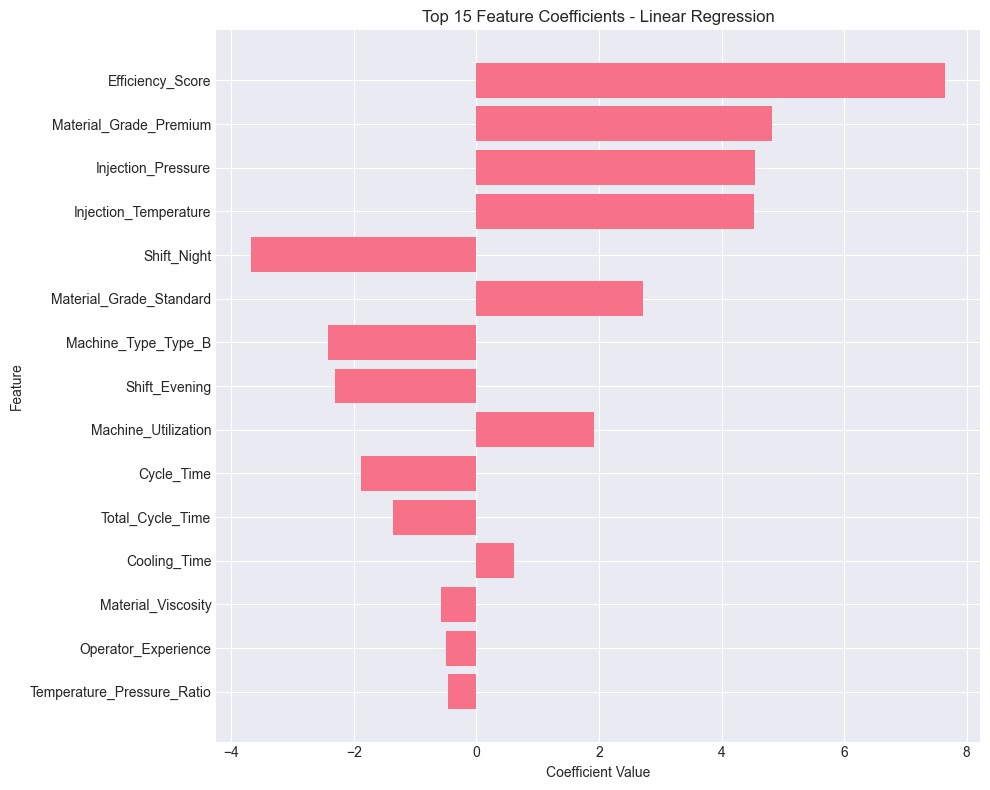


Top 10 Most Important Features (by coefficient magnitude):
                Feature  Coefficient
       Efficiency_Score     7.649820
 Material_Grade_Premium     4.830149
     Injection_Pressure     4.552226
  Injection_Temperature     4.528621
            Shift_Night    -3.681474
Material_Grade_Standard     2.718536
    Machine_Type_Type_B    -2.415654
          Shift_Evening    -2.308704
    Machine_Utilization     1.912169
             Cycle_Time    -1.889538


In [25]:
# Feature importance (for tree-based models)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
elif best_model_name == 'Linear Regression':
    # For linear regression, show coefficients
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(coef_df['Feature'][:15], coef_df['Coefficient'][:15])
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Top 15 Feature Coefficients - Linear Regression')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/feature_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 10 Most Important Features (by coefficient magnitude):")
    print(coef_df.head(10).to_string(index=False))

## 6. Save Models and Artifacts

In [28]:
# Save best model
import os 

os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print(f"Best model ({best_model_name}) saved to models/best_model.pkl")
print(f"Scaler saved to models/scaler.pkl")

# Save feature names
with open('../models/feature_names.json', 'w') as f:
    json.dump(X.columns.tolist(), f)
print("Feature names saved to models/feature_names.json")

# Save model metadata
metadata = {
    'best_model': best_model_name,
    'test_rmse': float(results_df.iloc[0]['Test RMSE']),
    'test_mae': float(results_df.iloc[0]['Test MAE']),
    'test_r2': float(results_df.iloc[0]['Test R²']),
    'test_mse': float(results_df.iloc[0]['Test MSE']),
    'n_features': int(X.shape[1]),
    'n_samples_train': int(X_train.shape[0]),
    'n_samples_test': int(X_test.shape[0])
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("Model metadata saved to models/model_metadata.json")

print("\nAll models and artifacts saved successfully!")

Best model (Linear Regression) saved to models/best_model.pkl
Scaler saved to models/scaler.pkl
Feature names saved to models/feature_names.json
Model metadata saved to models/model_metadata.json

All models and artifacts saved successfully!


## 7. Model Recommendations and Insights

In [29]:
print("=" * 80)
print("MODEL EVALUATION SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print(f"\n1. BEST MODEL: {best_model_name}")
print(f"   - Test RMSE: {results_df.iloc[0]['Test RMSE']:.4f} parts/hour")
print(f"   - Test R² Score: {results_df.iloc[0]['Test R²']:.4f}")
print(f"   - Interpretation: The model explains {results_df.iloc[0]['Test R²']*100:.2f}% of variance")

print("\n2. MODEL PERFORMANCE:")
if results_df.iloc[0]['Test R²'] > 0.8:
    print("   ✓ EXCELLENT: Model shows strong predictive performance")
elif results_df.iloc[0]['Test R²'] > 0.6:
    print("   ✓ GOOD: Model has acceptable predictive performance")
else:
    print("   ⚠ MODERATE: Model may need further optimization")

print("\n3. KEY INSIGHTS:")
print(f"   - Average prediction error: ±{results_df.iloc[0]['Test RMSE']:.2f} parts/hour")
print(f"   - Model is {'' if abs(results_df.iloc[0]['Train R²'] - results_df.iloc[0]['Test R²']) < 0.05 else 'NOT '}well-generalized")

print("\n4. BUSINESS RECOMMENDATIONS:")
print("   a) Production Optimization:")
print("      - Use model predictions to set optimal machine parameters")
print("      - Focus on features with highest importance/coefficients")
print("   b) Maintenance Planning:")
print("      - Monitor when actual output deviates significantly from predictions")
print("      - Schedule preventive maintenance based on model alerts")
print("   c) Quality Control:")
print("      - Set alert thresholds at ±2 RMSE from predictions")
print(f"      - Alert range: ±{2*results_df.iloc[0]['Test RMSE']:.2f} parts/hour")

print("\n5. NEXT STEPS:")
print("   - Deploy model via FastAPI for real-time predictions")
print("   - Monitor model performance over time")
print("   - Retrain quarterly with new production data")
print("   - Consider ensemble methods if higher accuracy needed")

print("\n" + "=" * 80)

MODEL EVALUATION SUMMARY & RECOMMENDATIONS

1. BEST MODEL: Linear Regression
   - Test RMSE: 3.1002 parts/hour
   - Test R² Score: 0.9369
   - Interpretation: The model explains 93.69% of variance

2. MODEL PERFORMANCE:
   ✓ EXCELLENT: Model shows strong predictive performance

3. KEY INSIGHTS:
   - Average prediction error: ±3.10 parts/hour
   - Model is well-generalized

4. BUSINESS RECOMMENDATIONS:
   a) Production Optimization:
      - Use model predictions to set optimal machine parameters
      - Focus on features with highest importance/coefficients
   b) Maintenance Planning:
      - Monitor when actual output deviates significantly from predictions
      - Schedule preventive maintenance based on model alerts
   c) Quality Control:
      - Set alert thresholds at ±2 RMSE from predictions
      - Alert range: ±6.20 parts/hour

5. NEXT STEPS:
   - Deploy model via FastAPI for real-time predictions
   - Monitor model performance over time
   - Retrain quarterly with new productio

In [30]:
print("\n🎉 ANALYSIS COMPLETE!")
print("\nGenerated artifacts:")
print("  - Models: best_model.pkl, scaler.pkl")
print("  - Visualizations: 10+ plots saved in reports/")
print("  - Data: model_comparison.csv, model_metadata.json")
print("\nReady for deployment! 🚀")


🎉 ANALYSIS COMPLETE!

Generated artifacts:
  - Models: best_model.pkl, scaler.pkl
  - Visualizations: 10+ plots saved in reports/
  - Data: model_comparison.csv, model_metadata.json

Ready for deployment! 🚀
